# Phase 0 — Data Exploration

**Dự án:** Vietnamese Legal RAG
**Mục tiêu notebook:** Khám phá và đánh giá chất lượng hai nguồn dữ liệu nền tảng của dự án trước khi bước vào Phase 1 (Ingestion):

1. **Corpus văn bản pháp luật** (`vbpl_sample.jsonl`) — nguồn dữ liệu chính để chunking + index hóa.
2. **Ground truth retrieval** (`retrieval_eval_train.jsonl`) — bộ câu hỏi/đáp chuẩn dùng để đánh giá độ chính xác của Retrieval Layer ở Phase 2.

**Nội dung notebook:**
- [1. Thiết lập môi trường](#1)
- [2. Khám phá corpus văn bản pháp luật](#2)
- [3. Khám phá dữ liệu ground truth retrieval](#3)
- [4. Kiểm tra tính nhất quán giữa hai nguồn dữ liệu](#4)
- [5. Tổng kết & khuyến nghị cho Phase 1](#5)

<a id='1'></a>
## 1. Thiết lập môi trường

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Đặt working directory về thư mục gốc của project
sys.path.append('..')

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (9, 4)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# --- Cấu hình đường dẫn (tập trung 1 chỗ để dễ chỉnh sửa) ---
VBPL_PATH = Path('../data/raw/laws/vbpl_sample.jsonl')
RETRIEVAL_EVAL_PATH = Path('../data/eval/retrieval_eval_train.jsonl')

# Giới hạn số dòng đọc mẫu cho tập ground truth (tránh tốn RAM với file lớn)
RETRIEVAL_SAMPLE_LIMIT = 1000

In [3]:
def load_jsonl(path: Path, limit: int | None = None) -> list[dict]:
    """Đọc file .jsonl thành list các dict.

    Args:
        path: Đường dẫn tới file .jsonl.
        limit: Nếu được cung cấp, chỉ đọc tối đa `limit` dòng đầu tiên.

    Returns:
        Danh sách các bản ghi đã parse từ JSON Lines.

    Raises:
        FileNotFoundError: Nếu file không tồn tại tại đường dẫn cho trước.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy file: {path.resolve()}\n"
            "Kiểm tra lại đường dẫn hoặc chạy script tải dữ liệu ở Phase 0 trước."
        )

    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit is not None and i >= limit:
                break
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[Cảnh báo] Bỏ qua dòng {i} do lỗi parse JSON: {e}")
    return records

<a id='2'></a>
## 2. Khám phá corpus văn bản pháp luật (`vbpl_sample.jsonl`)

Đây là dữ liệu văn bản pháp luật mẫu sẽ được đưa vào hệ thống Ingestion (chunking + index hóa) ở Phase 1.

In [4]:
vbpl_records = load_jsonl(VBPL_PATH)
df_vbpl = pd.DataFrame(vbpl_records)

print(f"Tổng số văn bản: {len(df_vbpl):,}")
print(f"Các cột hiện có: {list(df_vbpl.columns)}")
df_vbpl.head(2)

Tổng số văn bản: 100
Các cột hiện có: ['doc_name', 'item_id', 'scope', 'source', 'source_url', 'api_url', 'title', 'doc_type', 'legal_type', 'legal_area', 'doc_number', 'issue_date', 'year', 'issuing_authority', 'summary', 'markdown', 'num_pages', 'num_sections', 'num_paragraphs', 'num_sentences', 'char_len', 'text_hash', 'parser_model', 'parser_runtime', 'body_source', 'parsed_at', 'confidence', 'structure_json', 'extracted_json', 'file_paths_json']


,doc_name,item_id,scope,source,source_url,api_url,title,doc_type,legal_type,legal_area,...,char_len,text_hash,parser_model,parser_runtime,body_source,parsed_at,confidence,structure_json,extracted_json,file_paths_json
0,1,1,trung_uong,vbpl.vn,https://vbpl.vn/van-ban/chi-tiet/nghi-dinh-so-24-ld-nd-to-chuc-cac-co-quan-lao-dong-dia-phuong-lien-khu-va-tinh--1,https://vbpl-bientap-gateway.moj.gov.vn/api/qtdc/public/doc/1,Tổ chức các cơ quan Lao động địa phương liên khu và tỉnh,nghi_dinh,Nghị định,Chưa phân loại,...,1149,6bba1a9f1ebb47741d63ffa6b2d29313,local/markdownify,local,body_html,2026-05-21T10:37:41+00:00,None,"{""schema_version"": ""1.0"", ""doc_id"": ""1"", ""meta"": {""doc_id"": ""1"", ""doc_name"": ""1"", ""doc_type"": null, ""doc_subtype"": n...","{""doc_id"": ""1"", ""text_hash"": ""6bba1a9f1ebb47741d63ffa6b2d29313"", ""char_len"": 1149, ""entities"": [{""tag"": ""DATE"", ""tex...",None
1,10,10,trung_uong,vbpl.vn,https://vbpl.vn/van-ban/chi-tiet/thong-tu-so-41-nv-6-tt-dinh-the-le-xep-cong-chuc-vao-thang-luong-chung-theo-nang-lu...,https://vbpl-bientap-gateway.moj.gov.vn/api/qtdc/public/doc/10,Định thể lệ xếp công chức vào thang lương chung theo năng lực,thong_tu,Thông tư,Chưa phân loại,...,9007,7e65525e49a4ec387ad9fe4059a2c9be,local/markdownify,local,body_html,2026-05-21T10:37:41+00:00,None,"{""schema_version"": ""1.0"", ""doc_id"": ""10"", ""meta"": {""doc_id"": ""10"", ""doc_name"": ""10"", ""doc_type"": ""quyet_dinh"", ""doc_...","{""doc_id"": ""10"", ""text_hash"": ""7e65525e49a4ec387ad9fe4059a2c9be"", ""char_len"": 9007, ""entities"": [{""tag"": ""DATE"", ""te...",None


### 2.1. Kiểm tra chất lượng dữ liệu (missing values & trùng lặp)

Bước bắt buộc trước khi phân tích sâu hơn — dữ liệu thiếu hoặc trùng lặp nếu không phát hiện sớm sẽ làm sai lệch toàn bộ thống kê phía sau và ảnh hưởng trực tiếp đến chất lượng index ở Phase 1.

In [5]:
print("Số giá trị thiếu (null) theo từng cột:")
display(df_vbpl.isnull().sum())

if 'doc_id' in df_vbpl.columns:
    n_dup = df_vbpl['doc_id'].duplicated().sum()
    print(f"\nSố văn bản trùng doc_id: {n_dup}")
elif 'markdown' in df_vbpl.columns:
    n_dup = df_vbpl['markdown'].duplicated().sum()
    print(f"\nSố văn bản trùng nội dung (markdown): {n_dup}")

Số giá trị thiếu (null) theo từng cột:


doc_name               0
item_id                0
scope                  0
source                 0
source_url             0
api_url                0
title                  0
doc_type               0
legal_type             0
legal_area             0
doc_number             0
issue_date             0
year                   0
issuing_authority      0
summary              100
markdown               1
num_pages            100
num_sections           0
num_paragraphs         0
num_sentences          0
char_len               0
text_hash              1
parser_model           0
parser_runtime         0
body_source            0
parsed_at              0
confidence           100
structure_json         0
extracted_json         0
file_paths_json      100
dtype: int64


Số văn bản trùng nội dung (markdown): 0


### 2.2. Phân bố loại văn bản

In [6]:
for col in ['doc_type', 'legal_type']:
    if col in df_vbpl.columns:
        print(f"Phân bố theo '{col}':")
        display(df_vbpl[col].value_counts())
        print()
    else:
        print(f"[Bỏ qua] Không tìm thấy cột '{col}' trong dữ liệu.\n")

Phân bố theo 'doc_type':


doc_type
quyet_dinh    54
nghi_quyet    24
chi_thi       17
nghi_dinh      2
thong_tu       2
sac_lenh       1
Name: count, dtype: int64


Phân bố theo 'legal_type':


legal_type
Quyết định    54
Nghị quyết    24
Chỉ thị       17
Nghị định      2
Thông tư       2
Sắc lệnh       1
Name: count, dtype: int64

### 2.3. Phân tích độ dài văn bản

Độ dài văn bản (theo ký tự lẫn ước lượng số token) là yếu tố quyết định trực tiếp chiến lược chunking ở Phase 1 — văn bản càng dài, càng cần chunking theo ranh giới điều khoản thay vì cắt cứng.

In [7]:
df_vbpl['text_length_chars'] = df_vbpl['markdown'].fillna('').apply(len)

# Ước lượng nhanh số token (quy ước thô: ~1 token ≈ 4 ký tự với văn bản tiếng Việt có dấu
# qua BPE tokenizer phổ biến; chỉ dùng để có cảm nhận sơ bộ, không thay thế tokenizer thật)
df_vbpl['text_length_tokens_est'] = (df_vbpl['text_length_chars'] / 4).round().astype(int)

print("Thống kê độ dài văn bản (số ký tự):")
display(df_vbpl['text_length_chars'].describe())

print("\nThống kê độ dài văn bản (số token ước lượng):")
display(df_vbpl['text_length_tokens_est'].describe())

Thống kê độ dài văn bản (số ký tự):


count      100.000000
mean      7716.050000
std       9138.571291
min          0.000000
25%       2350.000000
50%       4149.000000
75%       9092.250000
max      55723.000000
Name: text_length_chars, dtype: float64


Thống kê độ dài văn bản (số token ước lượng):


count      100.000000
mean      1928.960000
std       2284.696421
min          0.000000
25%        587.750000
50%       1037.500000
75%       2273.000000
max      13931.000000
Name: text_length_tokens_est, dtype: float64

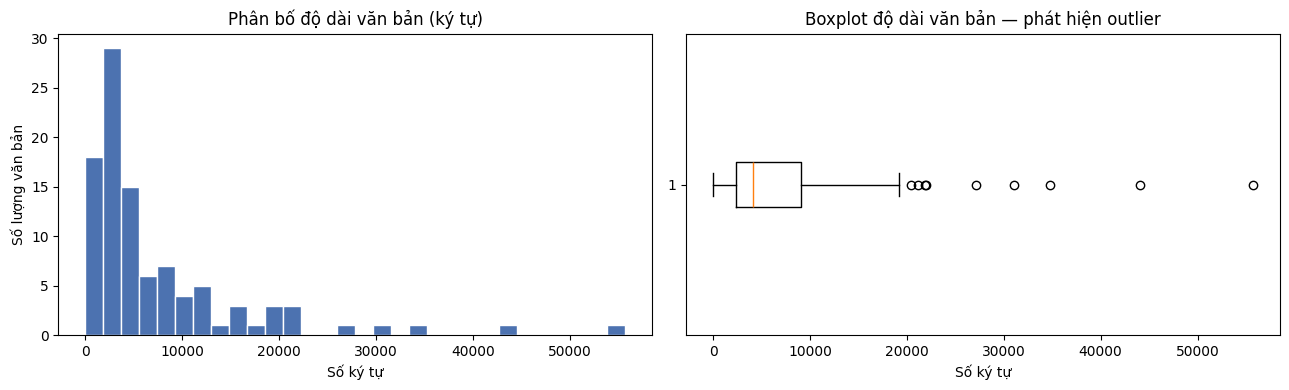

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_vbpl['text_length_chars'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Phân bố độ dài văn bản (ký tự)')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng văn bản')

axes[1].boxplot(df_vbpl['text_length_chars'], vert=False)
axes[1].set_title('Boxplot độ dài văn bản — phát hiện outlier')
axes[1].set_xlabel('Số ký tự')

plt.tight_layout()
plt.show()

In [9]:
# Xác định các văn bản dài bất thường (outlier) — cần lưu ý riêng khi thiết kế chunking
q99 = df_vbpl['text_length_chars'].quantile(0.99)
outliers = df_vbpl[df_vbpl['text_length_chars'] > q99]
print(f"Ngưỡng percentile 99: {q99:,.0f} ký tự")
print(f"Số văn bản vượt ngưỡng (outlier): {len(outliers)} / {len(df_vbpl)}")

Ngưỡng percentile 99: 44,154 ký tự
Số văn bản vượt ngưỡng (outlier): 1 / 100


<a id='3'></a>
## 3. Khám phá dữ liệu Ground Truth Retrieval (`retrieval_eval_train.jsonl`)

Dữ liệu này chứa câu hỏi và các đoạn văn bản mục tiêu (passage) liên quan — là tập chuẩn để đánh giá Recall@k/Precision@k của hệ thống retrieval ở Phase 2.

In [10]:
eval_records = load_jsonl(RETRIEVAL_EVAL_PATH, limit=RETRIEVAL_SAMPLE_LIMIT)
df_eval = pd.DataFrame(eval_records)

print(f"Số lượng câu hỏi đã load (giới hạn mẫu = {RETRIEVAL_SAMPLE_LIMIT}): {len(df_eval)}")
print(f"Các cột hiện có: {list(df_eval.columns)}")
df_eval.head(2)

Số lượng câu hỏi đã load (giới hạn mẫu = 1000): 1000
Các cột hiện có: ['question', 'context_list', 'qid', 'cid']


,question,context_list,qid,cid
0,"Liên đoàn Luật sư Việt Nam là tổ chức xã hội – nghề nghiệp có tư cách pháp nhân, có con dấu, tài khoản riêng?",[“Điều 2. Địa vị pháp lý của Liên đoàn Luật sư Việt Nam\n1. Liên đoàn Luật sư Việt Nam là tổ chức xã hội - nghề nghi...,72600,[142820]
1,Tên hợp tác xã bị rơi vào trường hợp cấm thì cơ quan nào có quyền từ chối chấp thuận đối với tên đó?,"[""Điều 7. Tên hợp tác xã, liên hiệp hợp tác xã\n1. Tên hợp tác xã, liên hiệp hợp tác xã được viết bằng tiếng Việt ho...",147562,"[27817, 72117]"


### 3.1. Xem chi tiết một bản ghi mẫu

In [11]:
sample_record = eval_records[0]

print("Câu hỏi:", sample_record.get('question'))
print("\nRelevant Passage IDs:", sample_record.get('relevant_passage_ids'))
print("\nSố lượng context được cung cấp kèm theo:", len(sample_record.get('context_list', [])))

Câu hỏi: Liên đoàn Luật sư Việt Nam là tổ chức xã hội – nghề nghiệp có tư cách pháp nhân, có con dấu, tài khoản riêng?

Relevant Passage IDs: None

Số lượng context được cung cấp kèm theo: 1


### 3.2. Phân bố số lượng passage liên quan trên mỗi câu hỏi

Chỉ số này quan trọng để chọn giá trị **k** phù hợp khi đánh giá Recall@k ở Phase 2 — nếu phần lớn câu hỏi chỉ có 1 passage liên quan, Recall@1 đã là một mốc đánh giá có ý nghĩa; nếu trung bình có nhiều passage liên quan, cần đánh giá ở k lớn hơn (Recall@5, Recall@10).

In [12]:
if 'relevant_passage_ids' in df_eval.columns:
    df_eval['n_relevant'] = df_eval['relevant_passage_ids'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    print("Thống kê số passage liên quan / câu hỏi:")
    display(df_eval['n_relevant'].describe())

    df_eval['n_relevant'].value_counts().sort_index().plot(
        kind='bar', color='#55A868', edgecolor='white'
    )
    plt.title('Phân bố số lượng passage liên quan trên mỗi câu hỏi')
    plt.xlabel('Số passage liên quan')
    plt.ylabel('Số câu hỏi')
    plt.tight_layout()
    plt.show()
else:
    print("[Bỏ qua] Không tìm thấy cột 'relevant_passage_ids'.")

[Bỏ qua] Không tìm thấy cột 'relevant_passage_ids'.


### 3.3. Kiểm tra dữ liệu thiếu / bất thường trong tập ground truth

Các câu hỏi không có passage liên quan nào (`n_relevant == 0`) cần được loại bỏ hoặc xử lý riêng trước khi dùng làm ground truth, vì chúng sẽ làm sai lệch chỉ số Recall/Precision khi đánh giá.

In [13]:
if 'n_relevant' in df_eval.columns:
    n_empty = (df_eval['n_relevant'] == 0).sum()
    print(f"Số câu hỏi không có passage liên quan nào: {n_empty} / {len(df_eval)} "
          f"({n_empty / len(df_eval):.1%})")

if 'question' in df_eval.columns:
    n_empty_question = df_eval['question'].fillna('').str.strip().eq('').sum()
    print(f"Số câu hỏi rỗng: {n_empty_question}")

Số câu hỏi rỗng: 0


<a id='4'></a>
## 4. Kiểm tra tính nhất quán giữa hai nguồn dữ liệu

Bước quan trọng thường bị bỏ qua: xác nhận rằng `relevant_passage_ids` trong tập ground truth thực sự trỏ được đến các văn bản/đoạn có trong corpus `vbpl_sample.jsonl`. Nếu tỷ lệ khớp thấp, cần làm rõ nguyên nhân (khác phiên bản dữ liệu, ID không đồng bộ...) trước khi dùng để đánh giá ở Phase 2 — nếu không, kết quả Recall@k đo được sẽ không phản ánh đúng chất lượng retrieval thật.

In [14]:
id_column_candidates = ['doc_id', 'passage_id', 'id']
corpus_id_col = next((c for c in id_column_candidates if c in df_vbpl.columns), None)

if corpus_id_col and 'relevant_passage_ids' in df_eval.columns:
    corpus_ids = set(df_vbpl[corpus_id_col].astype(str))

    all_relevant_ids = [
        str(pid)
        for ids in df_eval['relevant_passage_ids'].dropna()
        for pid in (ids if isinstance(ids, list) else [])
    ]
    matched = sum(1 for pid in all_relevant_ids if pid in corpus_ids)
    total = len(all_relevant_ids)

    match_rate = matched / total if total else 0
    print(f"Cột ID dùng để đối chiếu trong corpus: '{corpus_id_col}'")
    print(f"Tỷ lệ passage_id trong ground truth khớp với corpus: "
          f"{matched:,} / {total:,} ({match_rate:.1%})")

    if match_rate < 0.9:
        print("\n[Cảnh báo] Tỷ lệ khớp thấp hơn 90% — cần kiểm tra lại việc đồng bộ ID "
              "giữa hai nguồn dữ liệu trước khi dùng cho đánh giá Phase 2.")
else:
    print("[Bỏ qua] Không đủ cột cần thiết để đối chiếu (cần cột ID trong corpus và "
          "'relevant_passage_ids' trong ground truth).")

[Bỏ qua] Không đủ cột cần thiết để đối chiếu (cần cột ID trong corpus và 'relevant_passage_ids' trong ground truth).


<a id='5'></a>
## 5. Tổng kết & khuyến nghị cho Phase 1

**Về corpus văn bản pháp luật (`vbpl_sample.jsonl`):**
- Cần rà soát lại các giá trị thiếu/trùng lặp đã phát hiện ở mục 2.1 trước khi đưa vào pipeline ingestion.
- Với các văn bản outlier (dài bất thường, mục 2.3), nên ưu tiên áp dụng chunking theo ranh giới điều khoản/mục thay vì chunk cố định theo số ký tự, để tránh cắt rời ngữ cảnh pháp lý.

**Về dữ liệu ground truth retrieval (`retrieval_eval_train.jsonl`):**
- Loại bỏ các câu hỏi không có passage liên quan (`n_relevant == 0`) khỏi tập đánh giá chính thức.
- Dựa trên phân bố số passage liên quan/câu hỏi (mục 3.2), chọn các giá trị k phù hợp khi đo Recall@k, Precision@k ở Phase 2.

**Về tính nhất quán dữ liệu:**
- Nếu tỷ lệ khớp ID giữa hai nguồn (mục 4) thấp, cần xử lý đồng bộ ID trước khi dùng làm ground truth chính thức — đây là điều kiện tiên quyết để kết quả đánh giá retrieval ở Phase 2 đáng tin cậy.

**Bước tiếp theo:** chuyển sang notebook `02_chunking_experiments.ipynb` (Phase 1) để thử nghiệm các chiến lược chunking dựa trên các nhận định về độ dài văn bản đã phân tích ở trên.